# Transit Route Generation Evaluation

This notebook evaluates two approaches for transit network design:
- **LC (Learning-based Construction)** – pure neural route generator
- **Neural BCO (Bee Colony Optimization with neural initialization)**

Tested on **Mandl's benchmark** and **Tartu real-world network**.

---

## 1. Setup & Configuration

In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import pickle
from pathlib import Path
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader
from tqdm import tqdm

# Project-specific imports
from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.torch_utils import dump_routes
from connectpt.routes_generator import bee_colony
import connectpt.routes_generator.utils as lrnu

/root/transport/venv/lib/python3.12/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Root paths (adjust only here if needed)
ROOT_DIR = Path.cwd().parent.parent
DATA_DIR = ROOT_DIR / "examples/data"
CFG_DIR = ROOT_DIR / "connectpt/routes_generator/cfg"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples/data/model_weights/inductive_random_graphs_weighted_connectivity.pt"

# Verify paths
print("Root directory:", ROOT_DIR)
print("Config directory:", CFG_DIR)
print("Model weights exist:", MODEL_WEIGHTS_PATH.exists())

Root directory: /root/transport
Config directory: /root/transport/connectpt/routes_generator/cfg
Model weights exist: True


## 2. Load Benchmark Instances

### 2.1 Mandl's Benchmark (Classic 15-node instance)

In [3]:
def load_mandl_instance():
    data_dir = DATA_DIR / "benchmark"
    instance_name = "Mandl"

    # Coordinates
    coords_path = data_dir / f"{instance_name}Coords.txt"
    node_locs = torch.tensor(np.genfromtxt(coords_path, skip_header=1), dtype=torch.float32)

    # Travel times (in seconds)
    tt_path = data_dir / f"{instance_name}TravelTimes.txt"
    street_adj = torch.tensor(np.genfromtxt(tt_path), dtype=torch.float32) * 60

    # Demand matrix
    dmd_path = data_dir / f"{instance_name}Demand.txt"
    demand = torch.tensor(np.genfromtxt(dmd_path), dtype=torch.float32)

    print(f"Mandl instance loaded:")
    print(f"  Nodes: {node_locs.shape[0]}, Demand shape: {demand.shape}")

    return {
        'street_adj': street_adj,
        'demand': demand,
        'node_locs': node_locs
    }

### 2.2 Tartu Real-World Network (199 nodes)

In [4]:
def load_tartu_instance():
    data_dir = DATA_DIR / "tartu"

    # Load graph
    with open(data_dir / "bus_graph_Tartu.pkl", "rb") as f:
        G = pickle.load(f)

    # Load demand (OD matrix)
    OD = pd.read_csv(data_dir / "OD_matrix_Tartu.csv", index_col=0)
    demand = torch.tensor(OD.values, dtype=torch.float32)

    # Sort nodes to match OD matrix order
    nodes = sorted(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Node coordinates
    node_locs = torch.tensor([[G.nodes[n]['x'], G.nodes[n]['y']] for n in nodes], dtype=torch.float32)

    # Build symmetric travel time matrix
    n = len(nodes)
    inf = float('inf')
    adj_matrix = np.full((n, n), inf, dtype=np.float32)
    np.fill_diagonal(adj_matrix, 0.0)

    for u, v, data in G.edges(data=True):
        if 'time_min' in data:
            t = data['time_min']
            i, j = node_to_idx[u], node_to_idx[v]
            adj_matrix[i, j] = t
            adj_matrix[j, i] = t

    street_adj = torch.tensor(adj_matrix)
    street_adj[street_adj == inf] = torch.inf

    print(f"Tartu instance loaded: {n} nodes")

    return {
        'street_adj': street_adj,
        'demand': demand,
        'node_locs': node_locs
    }

In [5]:
# Uncomment to use Tartu instead
input_tensors = load_tartu_instance()
# input_tensors = load_mandl_instance()

Tartu instance loaded: 199 nodes


## 3. Evaluation Parameters

In [ ]:
eval_params = {
    "dataset_name": "tensor",
    "n_routes": 10,
    "min_route_len": 0,
    "max_route_len": 20,
    "demand_time_weight": 0.33,
    "route_time_weight": 0.33,
    "median_connectivity_weight": 0.33,
    "run_name": "mandl_eval",
    "model_weights": str(MODEL_WEIGHTS_PATH),
    "add_detour_penalty": False
}

: 

## 4. Method 1: Learning-based Construction (LC)

In [ ]:
# Load config
cfg_lc = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="eval_model_mumford",
    params=eval_params
)

# Build dataset and dataloader
test_ds = get_dataset_from_config(cfg_lc.eval.dataset, tensors=input_tensors)
test_dl = DataLoader(test_ds, batch_size=cfg_lc.batch_size)

# Initialize model
DEVICE, run_name_lc, _, cost_obj, model_lc = lrnu.process_standard_experiment_cfg(
    cfg_lc, run_name_prefix="lc_", weights_required=True
)

print(f"Running LC on {DEVICE}...")

_, unserved_lc, metrics_lc, routes_lc = eval_model(
    model_lc,
    test_dl,
    cfg_lc.eval,
    cost_obj,
    n_samples=cfg_lc.get("n_samples", 1),
    return_routes=True,
    silent=True,
    device=DEVICE
)

dump_routes(run_name_lc, routes_lc.cpu())

print("\nLC Results")
print("-" * 50)
print(f"Cost: {metrics_lc['cost'].item():.4f}")
print(f"Unserved demand (%): {metrics_lc['$d_{un}$'].item():.2f}")
print(f"Average Travel Time (ATT): {metrics_lc['ATT'].item():.4f}")
print(f"Routes:\n{routes_lc}")

/root/transport/connectpt/routes_generator/utils.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(cfg.model.weights,


Running LC on cpu...


## 5. Method 2: Neural Bee Colony Optimization (Neural BCO)

In [ ]:
# Use same parameters but switch to BCO config
bco_params = eval_params.copy()
bco_params.update({
    "run_name": "neural_bco_mandl",
    "starting_routes_init": "tensor"  # Use LC routes as warm-start
})

cfg_bco = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="neural_bco_mumford",
    params=bco_params
)

# Re-use same dataset
test_dl_bco = DataLoader(test_ds, batch_size=cfg_bco.batch_size)

# Initialize bee colony (with optional neural guidance)
use_neural_bees = cfg_bco.get("neural_bees", True)
prefix = "neural_bco_" if use_neural_bees else "bco_"

DEVICE, run_name_bco, sum_writer, cost_obj_bco, bee_model = lrnu.process_standard_experiment_cfg(
    cfg_bco, prefix, weights_required=True
)

if bee_model is not None:
    bee_model.eval()

print(f"Running Neural BCO (warm-started from LC)...")

test_output = lrnu.test_method(
    bee_colony,
    test_dl_bco,
    cfg_bco.eval,
    cfg_bco.init,
    cost_obj_bco,
    n_bees=cfg_bco.n_bees,
    n_iterations=cfg_bco.n_iterations,
    device=DEVICE,
    bee_model=bee_model,
    return_routes=True,
    routes_tensor=routes_lc,  # Warm-start!
    silent=True
)

routes_bco = test_output[-1]
metrics_bco = test_output[-2]
unserved_bco = test_output[-3]

dump_routes(run_name_bco, routes_bco)

print("\nNeural BCO Results")
print("-" * 50)
print(f"Cost: {metrics_bco['cost'].item():.4f}")
print(f"Unserved demand (%): {metrics_bco['$d_{un}$'].item():.2f}")
print(f"Average Travel Time (ATT): {metrics_bco['ATT'].item():.4f}")
print(f"Improvement vs LC: {(metrics_lc['cost'] - metrics_bco['cost']).item():.4f}")
print(f"Final routes:\n{routes_bco}")

Running Neural BCO (warm-started from LC)...

Neural BCO Results
--------------------------------------------------
Cost: 3.5113
Unserved demand (%): 7.77
Average Travel Time (ATT): 13.8057
Improvement vs LC: 0.7664
Final routes:
[[tensor([11, 10, 12,  9,  7,  5,  2,  1,  0]), tensor([ 4,  3,  5, 14,  6])]]


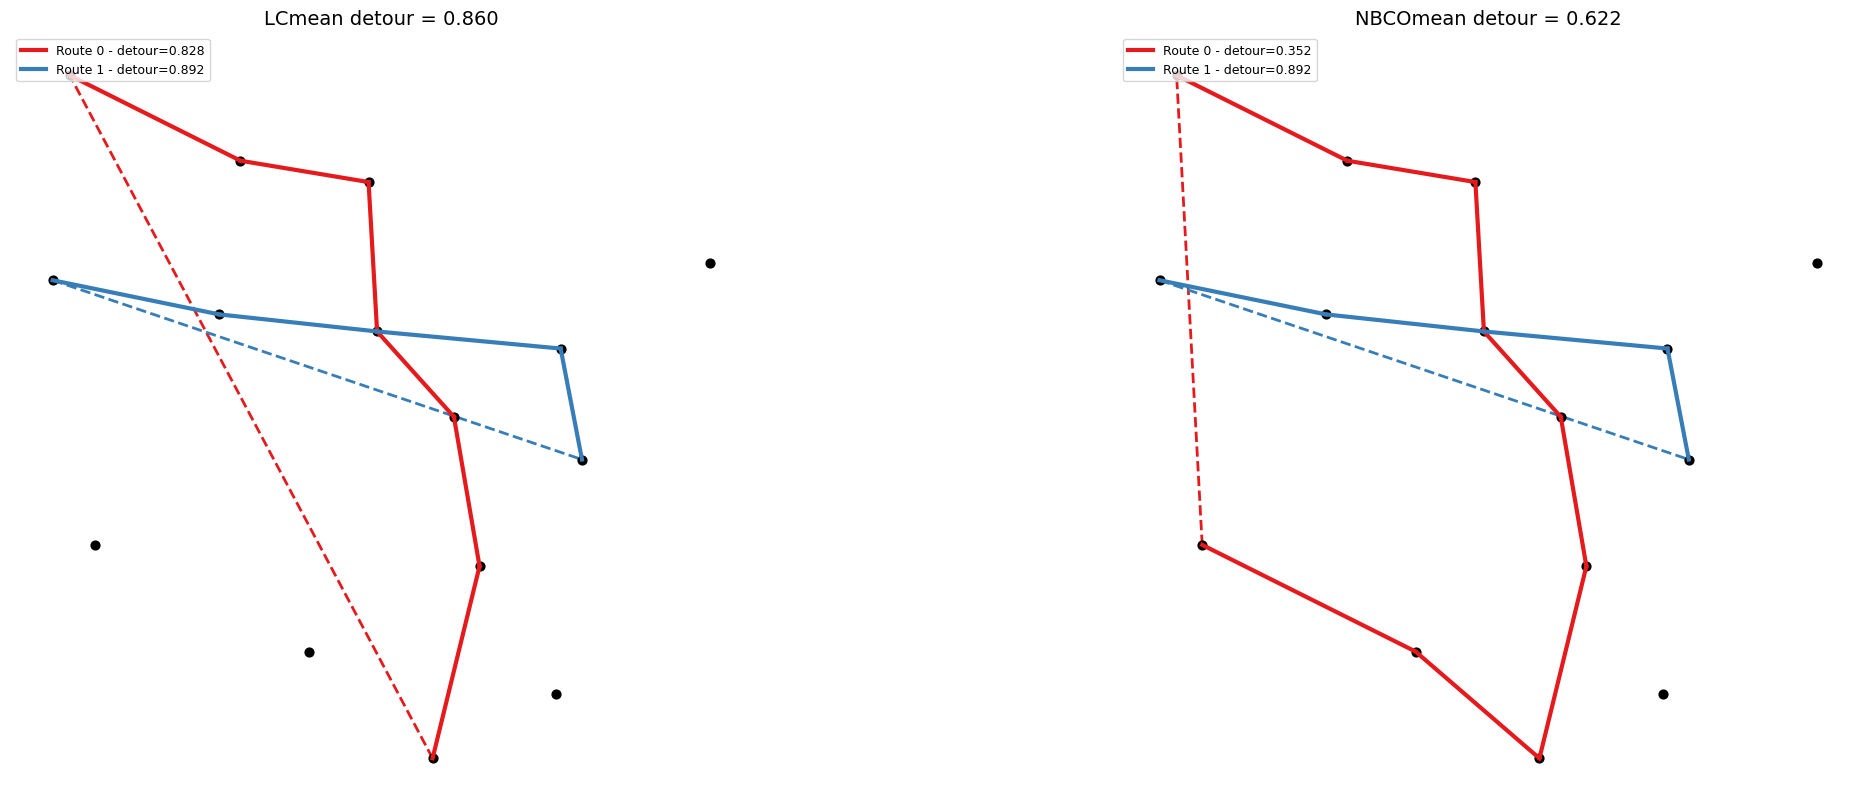

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from connectpt.routes_generator import torch_utils as tu


VIS_INSTANCE = "mandl"  # "mandl" or "tartu"


def to_numpy_routes(routes):
    if isinstance(routes, np.ndarray):
        arr = routes
    elif torch.is_tensor(routes):
        arr = routes.detach().cpu().numpy()
    else:
        arr = tu.get_batch_tensor_from_routes(routes).detach().cpu().numpy()
    if arr.ndim == 3:
        arr = arr[0]
    return arr


routes_lc_vis = to_numpy_routes(routes_lc)
routes_bco_vis = to_numpy_routes(routes_bco)


# ====================================================
# 1. Load data for visualization
# ====================================================


def load_travel_times(path, n_nodes):
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            row = [float("inf") if p.lower() == "inf" else float(p) for p in parts]
            if len(row) < n_nodes:
                row.extend([float("inf")] * (n_nodes - len(row)))
            rows.append(row[:n_nodes])
    return np.array(rows, dtype=float)


if VIS_INSTANCE == "mandl":
    data_dir = DATA_DIR / "benchmark"
    instance_name = "Mandl"

    coords_path = data_dir / f"{instance_name}Coords.txt"
    coords = np.genfromtxt(coords_path, skip_header=1)
    if coords.ndim == 1:
        coords = coords.reshape(-1, 2)

    tt_path = data_dir / f"{instance_name}TravelTimes.txt"
    travel_times = load_travel_times(tt_path, coords.shape[0])

    edge_geom = {}
    for u in range(coords.shape[0]):
        for v in range(coords.shape[0]):
            if u == v:
                continue
            if np.isfinite(travel_times[u, v]):
                edge_geom[(u, v)] = ((coords[u, 0], coords[u, 1]), (coords[v, 0], coords[v, 1]))

elif VIS_INSTANCE == "tartu":
    import pickle
    import momepy as mp

    data_dir = DATA_DIR / "tartu"
    with open(data_dir / "bus_graph_Tartu.pkl", "rb") as f:
        G = pickle.load(f)

    nodes_gdf, edges_gdf = mp.nx_to_gdf(G)
    if nodes_gdf.crs is not None:
        nodes_gdf = nodes_gdf.to_crs(3857)
        edges_gdf = edges_gdf.to_crs(3857)

    node_ids = sorted(nodes_gdf.index)
    node_id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    nodes_plot = nodes_gdf.loc[node_ids]
    coords = np.column_stack((nodes_plot.geometry.x.values, nodes_plot.geometry.y.values))

    edge_geom = {}
    for _, row in edges_gdf.iterrows():
        if "node_start" in row:
            u_id = row["node_start"]
            v_id = row["node_end"]
        else:
            u_id = row["u"]
            v_id = row["v"]
        if u_id in node_id_to_idx and v_id in node_id_to_idx:
            u = node_id_to_idx[u_id]
            v = node_id_to_idx[v_id]
            edge_geom[(u, v)] = row["geometry"]

else:
    raise ValueError(f"Unknown VIS_INSTANCE: {VIS_INSTANCE}")


# ====================================================
# 2. Draw single route
# ====================================================

def get_edge_geom(u, v):
    if (u, v) in edge_geom:
        return edge_geom[(u, v)]
    if (v, u) in edge_geom:
        return edge_geom[(v, u)]
    return None


def draw_route(route_nodes, ax, color="red", linewidth=2):
    route_nodes = [int(x) for x in route_nodes if x >= 0]

    for i in range(len(route_nodes) - 1):
        u = route_nodes[i]
        v = route_nodes[i + 1]

        geom = get_edge_geom(u, v)
        if geom is None:
            print(f"Missing edge: {u} <-> {v}")
            continue

        if hasattr(geom, "xy"):
            xs, ys = geom.xy
        else:
            (x1, y1), (x2, y2) = geom
            xs, ys = [x1, x2], [y1, y2]

        ax.plot(xs, ys, color=color, linewidth=linewidth, zorder=4)


# ====================================================
# 3. Detour index
# ====================================================

def compute_detour(route_nodes):
    route_nodes = [int(x) for x in route_nodes if x >= 0]
    if len(route_nodes) < 2:
        return None, None

    length = 0.0
    for i in range(len(route_nodes) - 1):
        u = route_nodes[i]
        v = route_nodes[i + 1]
        geom = get_edge_geom(u, v)
        if geom is None:
            continue
        if hasattr(geom, "length"):
            length += geom.length
        else:
            (x1, y1), (x2, y2) = geom
            length += np.hypot(x2 - x1, y2 - y1)

    x_start, y_start = coords[route_nodes[0]]
    x_end, y_end = coords[route_nodes[-1]]
    direct = np.hypot(x_end - x_start, y_end - y_start)

    if length <= 0:
        return None, None

    detour = direct / length
    return detour, ((x_start, y_start), (x_end, y_end))


# ====================================================
# 4. Plot LC vs NBCO (no basemap)
# ====================================================

def plot_routes(show_detour=True):
    tensors = [
        (routes_lc_vis, "LC"),
        (routes_bco_vis, "NBCO"),
    ]

    fig, axes = plt.subplots(1, len(tensors), figsize=(22, 8), constrained_layout=True)
    if len(tensors) == 1:
        axes = [axes]

    minx, miny = coords.min(axis=0)
    maxx, maxy = coords.max(axis=0)
    pad = 0.5

    palette = [
        "#e41a1c",
        "#377eb8",
        "#4daf4a",
        "#984ea3",
        "#ff7f00",
        "#ffff33",
        "#a65628",
        "#f781bf",
        "#999999",
        "#66c2a5",
        "#fc8d62",
        "#8da0cb",
        "#e78ac3",
        "#a6d854",
        "#ffd92f",
    ]

    for ax, (routes, title) in zip(axes, tensors):
        ax.set_xlim(minx - pad, maxx + pad)
        ax.set_ylim(miny - pad, maxy + pad)
        ax.set_aspect("equal")
        ax.axis("off")

        ax.scatter(coords[:, 0], coords[:, 1], s=40, color="black", zorder=3)

        detours = []
        legend_handles = []

        for i, route in enumerate(routes):
            color = palette[i % len(palette)]

            draw_route(route, ax, color=color, linewidth=3)

            detour_val, straight_geom = compute_detour(route)
            detours.append(detour_val)

            if show_detour and straight_geom is not None:
                (x1, y1), (x2, y2) = straight_geom
                ax.plot([x1, x2], [y1, y2], color=color, linestyle="--", linewidth=2, zorder=2)

            if show_detour:
                label = f"Route {i} - detour={detour_val:.3f}" if detour_val is not None else f"Route {i}"
            else:
                label = f"Route {i}"

            legend_handles.append(
                plt.Line2D([0], [0], color=color, lw=3, label=label)
            )

        mean_detour = np.mean([d for d in detours if d is not None])

        if show_detour:
            ax.set_title(f"{title}
mean detour = {mean_detour:.3f}", fontsize=14)
        else:
            ax.set_title(title, fontsize=14)

        ax.legend(handles=legend_handles, fontsize=9, loc="upper left")

    plt.show()


plot_routes(show_detour=True)


In [ ]:
# Running Neural BCO (warm-started from LC)...

# Neural BCO Results
# --------------------------------------------------
# Cost: 0.7824
# Unserved demand (%): 1.67
# Average Travel Time (ATT): 15.0655
# Improvement vs LC: 0.0089
# Final routes:
# [[tensor([7, 5, 2, 1, 0]), tensor([ 8, 14,  6,  9, 10]), tensor([12, 10, 11]), tensor([ 4,  3,  5, 14]), tensor([14,  7]), tensor([12, 13])]]

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# ========================================
# SETTINGS
# ========================================
pkl_files = [
    'neural_bco_exp_weighted_connectivity_mandl_pp_0_op_0_cp_1_generated.pkl',
    'neural_bco_exp_weighted_connectivity_mandl_pp_0_op_1_cp_0_generated.pkl',
    'neural_bco_exp_neuro_mandl_pp_0.9_op_0.1_cp_0.0_generated.pkl',
    'neural_bco_exp_weighted_connectivity_mandl_pp_1_op_0_cp_0_generated.pkl',
]

# --- Coordinates & travel-time matrix ---
coords_path = 'MandlCoords.txt'
with open(coords_path, 'r') as f:
    lines = [l.strip() for l in f.readlines() if l.strip()]
n_nodes = int(lines[0])
coords = np.array([list(map(float, line.split())) for line in lines[1:1+n_nodes]])
pos = {i: coords[i] for i in range(n_nodes)}

times_path = 'MandlTravelTimes.txt'
travel_times = []
with open(times_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        values = line.split()
        row = [float('inf') if v == 'Inf' else float(v) for v in values]
        while len(row) < n_nodes: row.append(float('inf'))
        row = row[:n_nodes]
        travel_times.append(row)
travel_times = np.array(travel_times, dtype=float)

# --- Background graph ---
G = nx.DiGraph()
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j and travel_times[i, j] < float('inf'):
            G.add_edge(i, j, weight=travel_times[i, j])

# --- Utility function for title/filename ---
def get_title_and_filename(fname):
    parts = fname.replace('.pkl', '').split('_')
    pp = parts[parts.index('pp') + 1]
    op = parts[parts.index('op') + 1]
    cp = parts[parts.index('cp') + 1]

    perspective = []
    if pp == '1': perspective.append('Passenger')
    if op == '1': perspective.append('Operator')
    if cp == '1': perspective.append('Connectivity')

    title = 'Route Set – ' + ' + '.join(perspective) if perspective else 'Route Set – None'
    short_name = '_'.join(perspective).lower().replace(' ', '_')
    if not short_name: short_name = 'none'
    return title, f'mandl_routes_{short_name}.png'

# ========================================
# PLOT: 3 subplots side by side, separate titles/legends
# ========================================
# ========================================
# PLOT: 4 subplots side by side, separate titles/legends
# ========================================
fig, axes = plt.subplots(1, 4, figsize=(34, 10), constrained_layout=True)  # ← 4 вместо 3
colors = plt.cm.Set1(np.linspace(0, 1, 10))
node_size = 300
offset_distance = 0.3

for fig_idx, pkl_path in enumerate(pkl_files):
    ax = axes[fig_idx]

    # --- Load routes ---
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    routes_tensor = data[0]
    print(f"Loaded {pkl_path}: {routes_tensor.shape[0]} routes")

    # --- Edge usage & order ---
    edge_order = {}
    for idx, route in enumerate(routes_tensor):
        route = [int(x) for x in route if x != -1]
        for k in range(len(route) - 1):
            u, v = route[k], route[k+1]
            edge_order.setdefault((u, v), []).append(idx)

    # --- Background edges ---
    for u, v, d in G.edges(data=True):
        x1, y1 = pos[u]; x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2], color='lightgray', lw=1.2, alpha=0.6, zorder=1)

    # --- Edge weights ---
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if travel_times[i, j] >= float('inf'): continue
            time = int(travel_times[i, j])
            x1, y1 = pos[i]; x2, y2 = pos[j]
            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
            perp = angle + 90
            offset = 0.25
            dx = offset * np.cos(np.radians(perp))
            dy = offset * np.sin(np.radians(perp))
            ax.text(mx + dx, my + dy, f'{time}', fontsize=8, fontweight='bold',
                    color='darkred', ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white',
                              edgecolor='red', linewidth=0.7, alpha=0.95),
                    rotation=angle, rotation_mode='anchor', zorder=3)

    # --- Nodes ---
    ax.scatter(coords[:, 0], coords[:, 1], c='black', s=node_size, zorder=5)
    for i, (x, y) in enumerate(coords):
        ax.text(x, y, str(i), fontsize=12, fontweight='bold', color='white',
                ha='center', va='center', zorder=6)

    # --- Routes ---
    handles = []
    for idx, route_tensor in enumerate(routes_tensor):
        route = [int(x) for x in route_tensor if x != -1]
        if len(route) < 2: continue
        color = colors[idx % len(colors)]
        total_time = int(sum(travel_times[route[k], route[k+1]] for k in range(len(route) - 1)))

        segments = []
        for k in range(len(route) - 1):
            u, v = route[k], route[k+1]
            x1, y1 = pos[u]; x2, y2 = pos[v]
            dx, dy = x2 - x1, y2 - y1
            length = np.hypot(dx, dy)
            if length == 0: continue
            ux, uy = dx / length, dy / length
            px, py = -uy, ux
            order_list = edge_order.get((u, v), [])
            pos_in_edge = order_list.index(idx) if idx in order_list else 0
            total = len(order_list)
            offset_factor = (pos_in_edge - (total - 1) / 2) if total > 0 else 0
            offset = offset_factor * offset_distance
            ox = px * offset
            oy = py * offset
            x1o, y1o = x1 + ox, y1 + oy
            x2o, y2o = x2 + ox, y2 + oy
            segments.append([(x1o, y1o), (x2o, y2o)])

        if segments:
            line_x = [p[0] for seg in segments for p in seg]
            line_y = [p[1] for seg in segments for p in seg]
            ax.plot(line_x, line_y, color=color, linewidth=4, alpha=0.9, zorder=4)

        # Arrows
        for k in range(len(route) - 1):
            u, v = route[k], route[k+1]
            x1, y1 = pos[u]; x2, y2 = pos[v]
            dx, dy = x2 - x1, y2 - y1
            length = np.hypot(dx, dy)
            if length == 0: continue
            ux, uy = dx / length, dy / length
            px, py = -uy, ux
            order_list = edge_order.get((u, v), [])
            pos_in_edge = order_list.index(idx) if idx in order_list else 0
            total = len(order_list)
            offset_factor = (pos_in_edge - (total - 1) / 2) if total > 0 else 0
            offset = offset_factor * offset_distance
            ox = px * offset
            oy = py * offset
            x1o, y1o = x1 + ox, y1 + oy
            x2o, y2o = x2 + ox, y2 + oy
            ax.annotate('', xy=(x2o, y2o), xytext=(x1o, y1o),
                        arrowprops=dict(arrowstyle='->', color=color, lw=2.2, alpha=0.8),
                        zorder=4)

        # Legend handle
        path_str = ' → '.join(map(str, route))
        label = f'Route {idx}: {path_str} ({total_time} min)'
        handles.append(plt.Line2D([0], [0], color=color, lw=5, label=label))

    # --- Title & Legend under plot ---
    title, _ = get_title_and_filename(pkl_path)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_aspect('equal')
    ax.axis('off')

    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.05),
              fontsize=10, ncol=1, frameon=True, fancybox=True, title='Routes', title_fontsize=11)

# --- Save the full figure with 3 plots ---
plt.savefig('mandl_routes_side_by_side.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'MandlCoords.txt'

In [ ]:
БЕЗ ДЕТУРА

Neural BCO Results
--------------------------------------------------
Cost: 0.3835
Unserved demand (%): 0.06
Average Travel Time (ATT): 14.1606
Improvement vs LC: 0.0201
Final routes:
[[tensor([ 0,  1,  2,  5,  7,  9, 10]), tensor([11,  3,  5, 14,  6]), tensor([13, 12, 10]), tensor([ 8, 14]), tensor([ 7, 14]), tensor([4, 3])]]
/root/transport/transport/routes_generator/utils.py:319: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)

In [ ]:

LC Results
--------------------------------------------------
Cost: 0.7913
Unserved demand (%): 0.00
Average Travel Time (ATT): 12.5106
Routes:
tensor([[[ 0,  1,  2,  5,  7,  9, 13],
         [ 8, 14,  6,  9, 10, -1, -1],
         [12, 10, 11, -1, -1, -1, -1],
         [ 4,  3,  5, 14, -1, -1, -1],
         [14,  7, -1, -1, -1, -1, -1],
         [12, 13, -1, -1, -1, -1, -1]]])
/root/transport/transport/routes_generator/utils.py:319: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)

## 6. Summary Comparison

In [ ]:
### 6. Summary Comparison (fixed)

print("=" * 60)
print("Final Comparison".center(60))
print("=" * 60)
print(f"{'Method':<15} {'Cost':<10} {'Unserved (%)':<15} {'ATT':<10} {'Time (s)':<10}")
print("-" * 60)

def _val(d, key, default=0.0):
    """Safely extract scalar from tensor or return default."""
    v = d.get(key, torch.tensor(default))
    return v.item() if hasattr(v, "item") else float(v)

# LC row
lc_cost   = _val(metrics_lc, 'cost')
lc_un     = _val(metrics_lc, '$d_{un}$')
lc_att    = _val(metrics_lc, 'ATT')
lc_time   = _val(metrics_lc, 'average wall-clock duration', 0)

# Neural BCO row
bco_cost  = _val(metrics_bco, 'cost')
bco_un    = _val(metrics_bco, '$d_{un}$')
bco_att   = _val(metrics_bco, 'ATT')
bco_time  = _val(metrics_bco, 'average wall-clock duration', 0)

print(f"{'LC':<15} {lc_cost:<10.4f} {lc_un:<15.2f} {lc_att:<10.4f} {lc_time:<10.1f}")
print(f"{'Neural BCO':<15} {bco_cost:<10.4f} {bco_un:<15.2f} {bco_att:<10.4f} {bco_time:<10.1f}")

# Optional: improvement highlight
if bco_cost < lc_cost:
    improvement = lc_cost - bco_cost
    print(f"\nNeural BCO improves cost by {improvement:.4f} ({improvement/lc_cost*100:.2f}% better)")